In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Cargar dataset
data = fetch_california_housing()

X = data.data
y = data.target

# Convertir a DataFrame para explorar mejor
df = pd.DataFrame(X, columns=data.feature_names)
df["Price"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


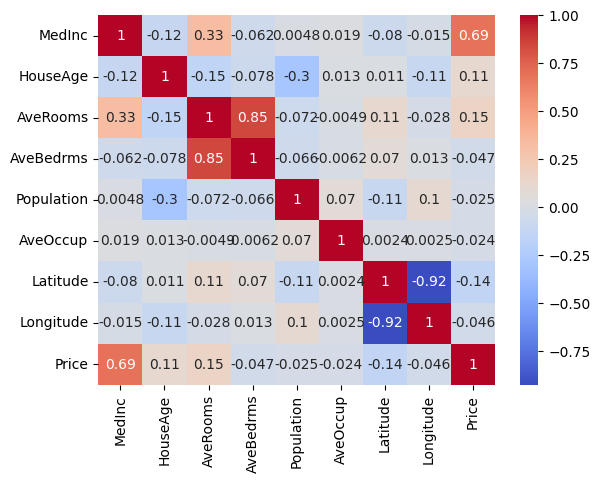

In [5]:
# Correlación
import seaborn as sns
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Predicciones
y_train_pred = lin_model.predict(X_train)
y_test_pred = lin_model.predict(X_test)

In [8]:
# Train
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Test
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Regresión Lineal:")
print("Train -> MSE:", mse_train, "R2:", r2_train)
print("Test  -> MSE:", mse_test, "R2:", r2_test)

Regresión Lineal:
Train -> MSE: 0.5179331255246699 R2: 0.6125511913966952
Test  -> MSE: 0.5558915986952422 R2: 0.5757877060324524


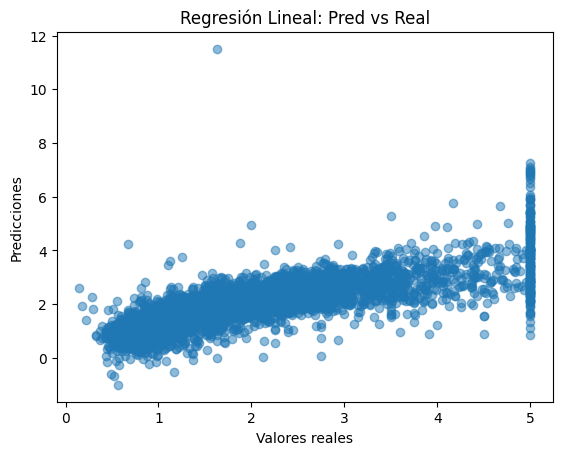

In [9]:
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal: Pred vs Real")
plt.show()

In [10]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predicciones
y_train_poly_pred = poly_model.predict(X_train_poly)
y_test_poly_pred = poly_model.predict(X_test_poly)

In [11]:
mse_train_poly = mean_squared_error(y_train, y_train_poly_pred)
r2_train_poly = r2_score(y_train, y_train_poly_pred)

mse_test_poly = mean_squared_error(y_test, y_test_poly_pred)
r2_test_poly = r2_score(y_test, y_test_poly_pred)

print("\nRegresión Polinómica (grado 2):")
print("Train -> MSE:", mse_train_poly, "R2:", r2_train_poly)
print("Test  -> MSE:", mse_test_poly, "R2:", r2_test_poly)


Regresión Polinómica (grado 2):
Train -> MSE: 0.4207266151573573 R2: 0.6852681982344941
Test  -> MSE: 0.4643015259451211 R2: 0.6456819713121914


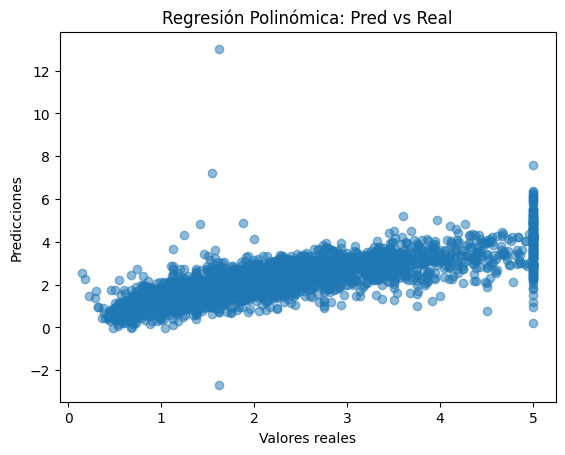

In [17]:
plt.scatter(y_test, y_test_poly_pred, alpha=0.5)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Polinómica: Pred vs Real")
plt.show()

In [21]:
# Análisis de coeficientes - Feature importance
coefficients = lin_model.coef_
feature_names = data.feature_names

# Crear un DataFrame con los coeficientes ordenados por valor absoluto
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': coefficients,
    'Valor Absoluto': np.abs(coefficients)
}).sort_values('Valor Absoluto', ascending=False)

print("Coeficientes del modelo (ordenados por impacto):")
print(coef_df)
print("\nFeature con mayor impacto:", coef_df.iloc[0]['Feature'])
print("Coeficiente:", coef_df.iloc[0]['Coeficiente'])

Coeficientes del modelo (ordenados por impacto):
      Feature  Coeficiente  Valor Absoluto
3   AveBedrms     0.783145        0.783145
0      MedInc     0.448675        0.448675
7   Longitude    -0.433708        0.433708
6    Latitude    -0.419792        0.419792
2    AveRooms    -0.123323        0.123323
1    HouseAge     0.009724        0.009724
5    AveOccup    -0.003526        0.003526
4  Population    -0.000002        0.000002

Feature con mayor impacto: AveBedrms
Coeficiente: 0.7831449067929727


## Que es el MSE
El MSE mide qué tan lejos están las predicciones de los valores reales.
MSE= 1/n ∑(yreal​−ypred​)²
De aca podemos sacar de que:
- Calcula el error en cada prediccion
- Lo eleva al cuadrado, lo cual penaliza más los errores grandes
- Hace el promedio

Podemos decir entonces de que calcula el error promedio del modelo

Cómo leerlo
Más bajo = mejor
0 = predicción perfecta

Ejemplo:

MSE = 0.2 → error bajo
MSE = 1.5 → error alto

---

## Que es el R² (Coeficiente de determinación)
El R² mide qué tan bien el modelo explica los datos.

Va normalmente entre 0 y 1
Indica qué porcentaje de la variación de los datos explica el modelo

R² = 1 → modelo perfecto
R² = 0 → no explica nada
R² < 0 → peor que adivinar

Ejemplo:
R² = 0.80
→ el modelo explica el 80% del comportamiento de los precios

## ¿Cuál modelo es mejor? ¿Cómo lo determinaron?

Para determinar cuál modelo es mejor, se compararon las métricas de desempeño en el conjunto de test, específicamente el coeficiente de determinación (R²) y el error cuadrático medio (MSE).

Resultados obtenidos:

- Regresión lineal:
  - R² (test): 0.57
  - MSE (test): 0.55

- Regresión polinómica:
  - R² (test): 0.64
  - MSE (test): 0.46

El mejor modelo es aquel que presenta un mayor R² y un menor MSE en test, ya que esto indica una mejor capacidad de generalización.

En este caso, el modelo polinomico es mejor.

---

## ¿Hay señales de overfitting en alguno? ¿Cómo se dan cuenta?

El overfitting se identifica cuando el modelo tiene un rendimiento significativamente mejor en el conjunto de entrenamiento que en el de test.

Resultados:

- Regresión lineal:
  - R² train: 0.61
  - R² test: 0.57

- Regresión polinómica:
  - R² train: 0.68
  - R² test: 0.64


Como tal no se puede ver una diferencia demasiado grande entre el r2 de entrenamiento y el r2 de test en ninguno de los 2 modelos.

Seria overffiting si hubiera una diferencia de aprox 20%

---

## ¿Qué feature tiene más impacto en el precio? ¿Cómo lo averiguaron?

Para determinar la variable más influyente, se analizaron los coeficientes del modelo de regresión lineal.

La variable con mayor impacto es aquella con el coeficiente más alto en valor absoluto.

Resultados (ordenados por impacto):

- AveBedrms (Promedio de Dormitorios) → coef: 0.783145  
- MedInc (Ingreso Medio) → coef: 0.448675  
- Longitude (Longitud) → coef: -0.433708
- Latitude (Latitud) → coef: -0.419792

Se observa que **AveBedrms** (promedio de dormitorios por casa) tiene el mayor coeficiente, lo que indica que es la variable que más influye en el precio de las viviendas.

Esto implica que, a mayor número promedio de dormitorios en una propiedad, mayor tiende a ser su valor. Un aumento de 1 dormitorio promedio aumenta el precio en aproximadamente 0.78 unidades (en la escala del dataset, que es de 100,000 dólares).

Esto tiene mucho sentido económico: el número de habitaciones es un factor crítico en la valoración de propiedades residenciales.

